# TMS / FLOW Extended — Time Series EDA

**데이터**
- `data/actual/TMS_extended.csv` : 2024-08-26 ~ 2026-02-23 (1분 간격, ~72만 행)
- `data/actual/FLOW_extended.csv` : 2025-11-22 ~ 2026-02-23 (1분 간격, ~13만 행)

**출력 경로** : `results/timeseries/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 0.6,
})

BASE   = Path('../../')
OUT    = BASE / 'results' / 'timeseries'
OUT.mkdir(parents=True, exist_ok=True)
print('Output dir:', OUT.resolve())

Output dir: C:\project_WWTP\python\results\timeseries


## 1. 데이터 로드

In [2]:
tms = pd.read_csv(BASE / 'data/actual/TMS_extended.csv', parse_dates=['SYS_TIME'])
tms.sort_values('SYS_TIME', inplace=True)
tms.set_index('SYS_TIME', inplace=True)

flow = pd.read_csv(BASE / 'data/actual/FLOW_extended.csv', parse_dates=['SYS_TIME'])
flow.sort_values('SYS_TIME', inplace=True)
flow.set_index('SYS_TIME', inplace=True)

print('TMS  :', tms.shape,  '|', tms.index[0], '~', tms.index[-1])
print('FLOW :', flow.shape, '|', flow.index[0], '~', flow.index[-1])
tms.head(3)

TMS  : (726665, 6) | 2024-08-26 15:09:00 ~ 2026-02-23 14:04:00
FLOW : (132297, 15) | 2025-11-22 23:52:00 ~ 2026-02-23 13:58:00


,TOC_VU,PH_VU,SS_VU,FLUX_VU,TN_VU,TP_VU
SYS_TIME,,,,,,
2024-08-26 15:09:00,4.1,7.2,0.9,3912.0,11.923,0.039
2024-08-26 15:10:00,4.1,7.2,0.8,3917.0,11.923,0.039
2024-08-26 15:11:00,4.1,7.1,0.9,3923.0,11.923,0.039


In [3]:
# 기초 통계
print('=== TMS 기초 통계 ===')
display(tms.describe().round(3))
print('\n=== FLOW 기초 통계 ===')
display(flow.describe().round(3))

=== TMS 기초 통계 ===


,TOC_VU,PH_VU,SS_VU,FLUX_VU,TN_VU,TP_VU
count,623908.000,623908.000,623908.000,623913.000,623912.000,623908.000
mean,5.892,7.049,1.212,29095.364,7.044,0.085
std,9.351,0.327,2.583,354396.570,5.187,0.745
min,0.000,0.000,0.000,-3496630.000,0.000,0.000
25%,3.700,6.900,0.600,1706.000,5.188,0.025
50%,5.300,7.100,0.600,3241.000,6.889,0.035
75%,6.900,7.200,1.500,5059.000,8.761,0.048
max,496.700,15.800,91.000,6068990.000,97.096,18.272



=== FLOW 기초 통계 ===


,flow_TankA,flow_TankB,wind1,wind2,pumpA,pumpB,pumpC,BOD_in,COD_in,PH_in,SS_in,TN_in,TOC_in,TP_in,WATER_TEMP_in
count,132297.000,132297.000,132297.000,132297.000,132297.000,132297.000,132297.000,132297.000,132297.000,132297.000,132297.000,132297.000,132297.000,132297.000,132297.000
mean,173.421,175.765,1232.591,899.713,25.834,0.418,28.386,399.473,182.906,6.271,548.506,82.359,238.928,11.670,18.639
std,46.722,41.580,350.374,316.487,2.353,5.776,9.421,246.953,247.989,0.814,627.756,142.239,311.172,12.972,1.701
min,0.000,0.000,2.031,0.000,0.000,0.000,0.000,0.000,0.000,4.014,0.000,0.000,0.000,0.000,10.338
25%,169.575,169.725,1261.719,819.375,24.275,0.019,24.869,339.599,21.300,5.573,265.087,33.878,132.376,7.757,17.491
50%,189.862,189.900,1296.875,995.781,25.556,0.038,26.000,339.599,174.382,6.605,265.087,81.089,132.376,8.020,18.594
75%,199.838,199.875,1322.500,1057.969,26.956,0.056,29.844,454.470,174.406,6.853,501.185,81.089,132.376,9.014,19.838
max,318.412,290.175,1747.031,1332.812,55.862,90.244,100.000,1000.000,1000.000,9.490,2000.000,1000.000,1000.000,50.000,23.006


## 2. TMS — 원시 시계열

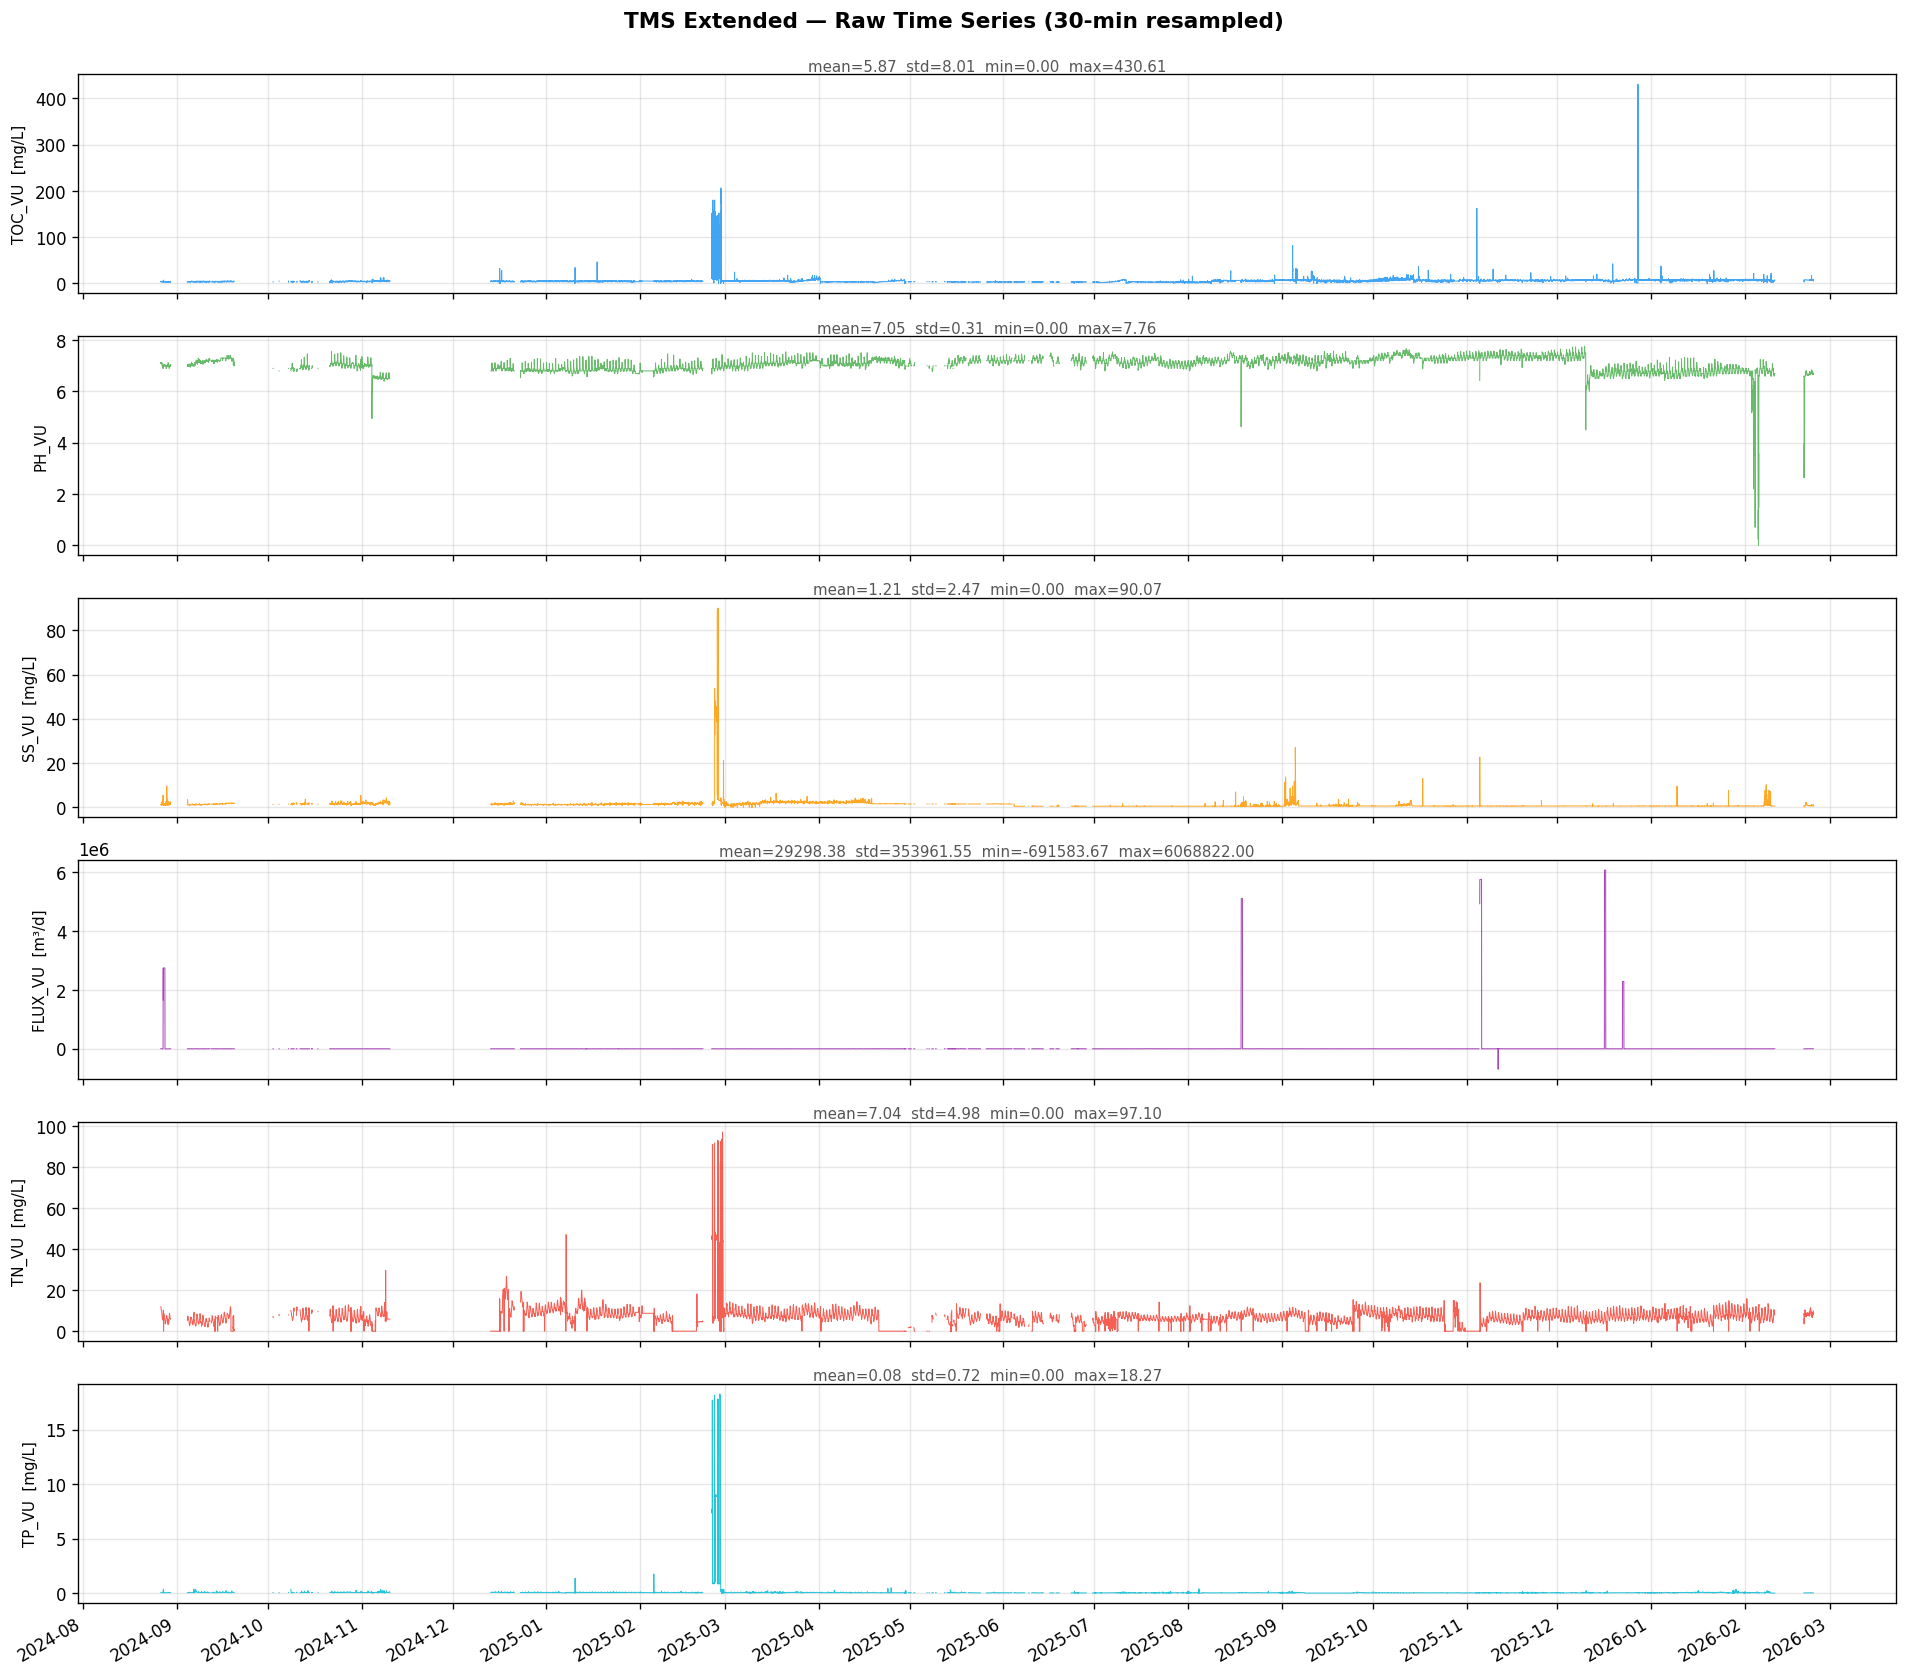

Saved: tms_extended_timeseries.png


In [4]:
TMS_COLS = ['TOC_VU', 'PH_VU', 'SS_VU', 'FLUX_VU', 'TN_VU', 'TP_VU']
TMS_UNITS = ['mg/L', '', 'mg/L', 'm³/d', 'mg/L', 'mg/L']
TMS_COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

# 30분 리샘플로 시각화 (약 70만 행 → 빠른 렌더링)
tms_30m = tms[TMS_COLS].resample('30min').mean()

fig, axes = plt.subplots(len(TMS_COLS), 1, figsize=(16, 14), sharex=True)
fig.suptitle('TMS Extended — Raw Time Series (30-min resampled)', fontsize=13, fontweight='bold', y=0.995)

for ax, col, unit, color in zip(axes, TMS_COLS, TMS_UNITS, TMS_COLORS):
    ax.plot(tms_30m.index, tms_30m[col], color=color, alpha=0.85)
    label = f'{col}  [{unit}]' if unit else col
    ax.set_ylabel(label, fontsize=9)
    # 통계 텍스트
    s = tms_30m[col].dropna()
    ax.set_title(
        f'mean={s.mean():.2f}  std={s.std():.2f}  min={s.min():.2f}  max={s.max():.2f}',
        fontsize=9, color='#555555', pad=2
    )

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
fig.savefig(OUT / 'tms_extended_timeseries.png', bbox_inches='tight')
plt.show()
print('Saved: tms_extended_timeseries.png')

## 3. TMS — 분포 (Histogram + Boxplot)

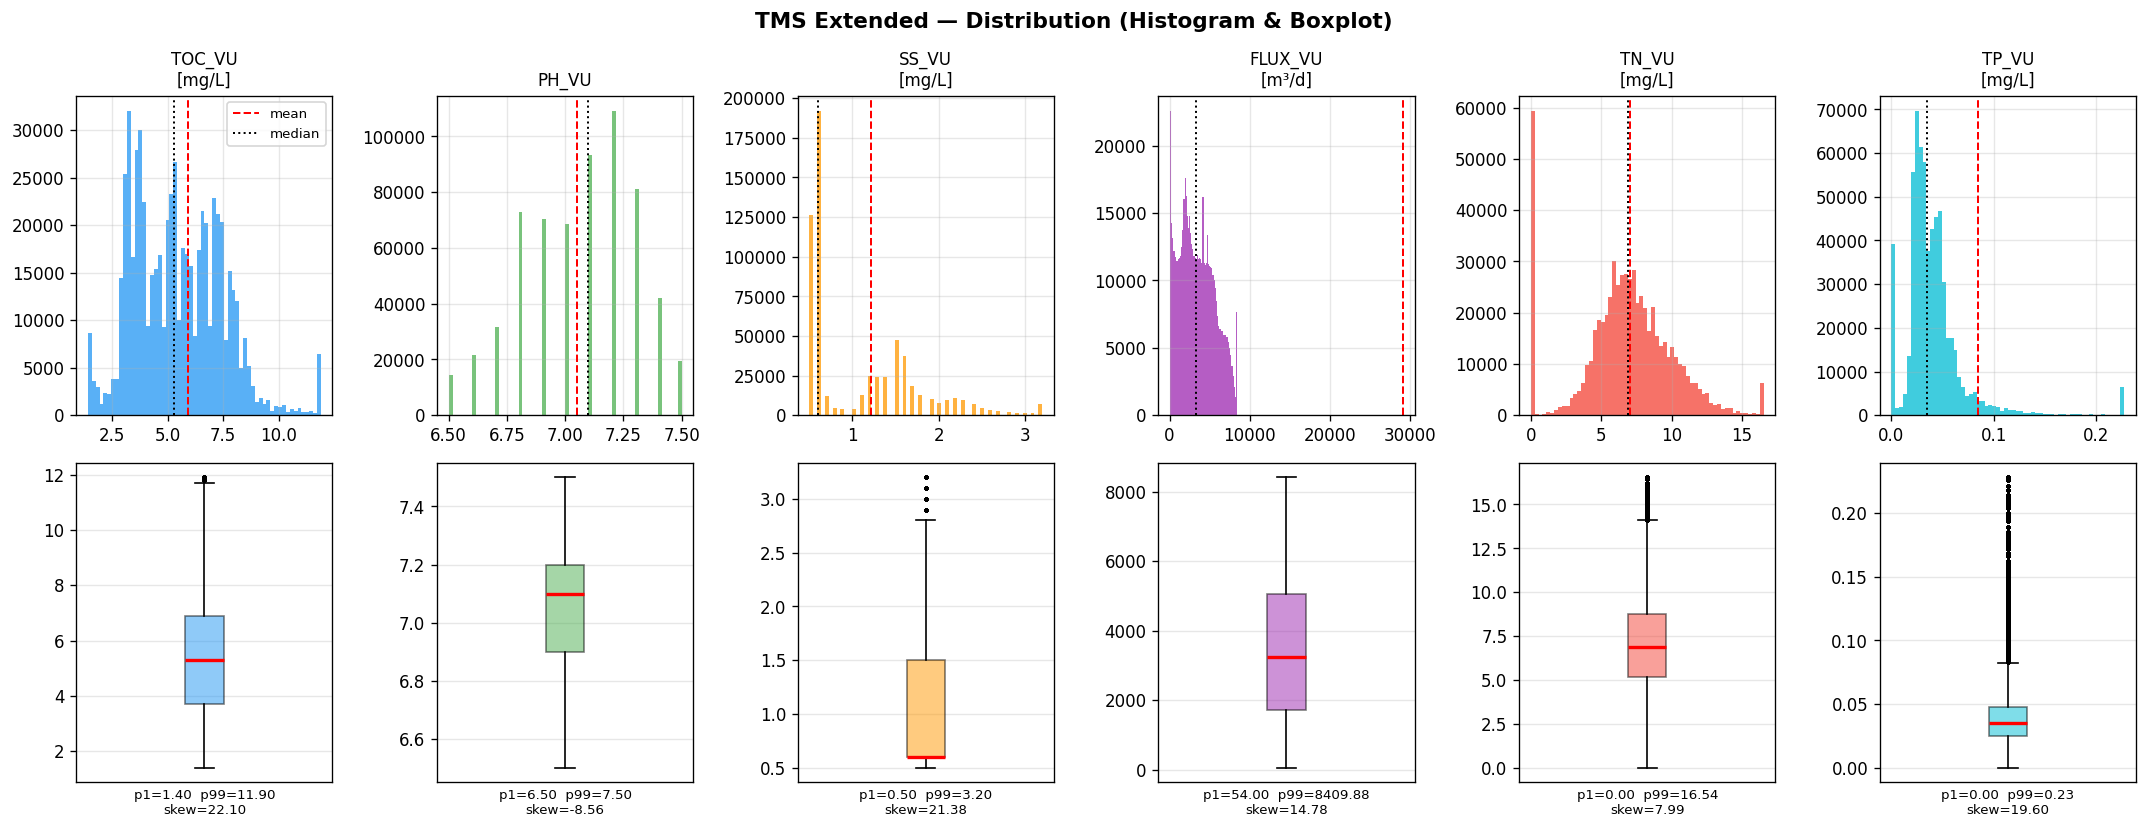

Saved: tms_extended_distribution.png


In [5]:
fig, axes = plt.subplots(2, len(TMS_COLS), figsize=(18, 7))
fig.suptitle('TMS Extended — Distribution (Histogram & Boxplot)', fontsize=13, fontweight='bold')

for i, (col, unit, color) in enumerate(zip(TMS_COLS, TMS_UNITS, TMS_COLORS)):
    s = tms[col].dropna()
    q1, q3 = s.quantile(0.01), s.quantile(0.99)
    s_clip = s.clip(q1, q3)

    # Histogram
    ax_h = axes[0, i]
    ax_h.hist(s_clip, bins=60, color=color, alpha=0.75, edgecolor='none')
    label = f'{col}\n[{unit}]' if unit else col
    ax_h.set_title(label, fontsize=10)
    ax_h.axvline(s.mean(), color='red', lw=1.2, linestyle='--', label='mean')
    ax_h.axvline(s.median(), color='black', lw=1.2, linestyle=':', label='median')
    if i == 0:
        ax_h.legend(fontsize=8)

    # Boxplot
    ax_b = axes[1, i]
    bp = ax_b.boxplot(s_clip, vert=True, patch_artist=True,
                      medianprops=dict(color='red', lw=2),
                      boxprops=dict(facecolor=color, alpha=0.5),
                      whiskerprops=dict(lw=1),
                      flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
    ax_b.set_xticks([])
    ax_b.set_xlabel(
        f'p1={q1:.2f}  p99={q3:.2f}\nskew={s.skew():.2f}',
        fontsize=8
    )

plt.tight_layout()
fig.savefig(OUT / 'tms_extended_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: tms_extended_distribution.png')

## 4. FLOW — 원시 시계열 (그룹별)

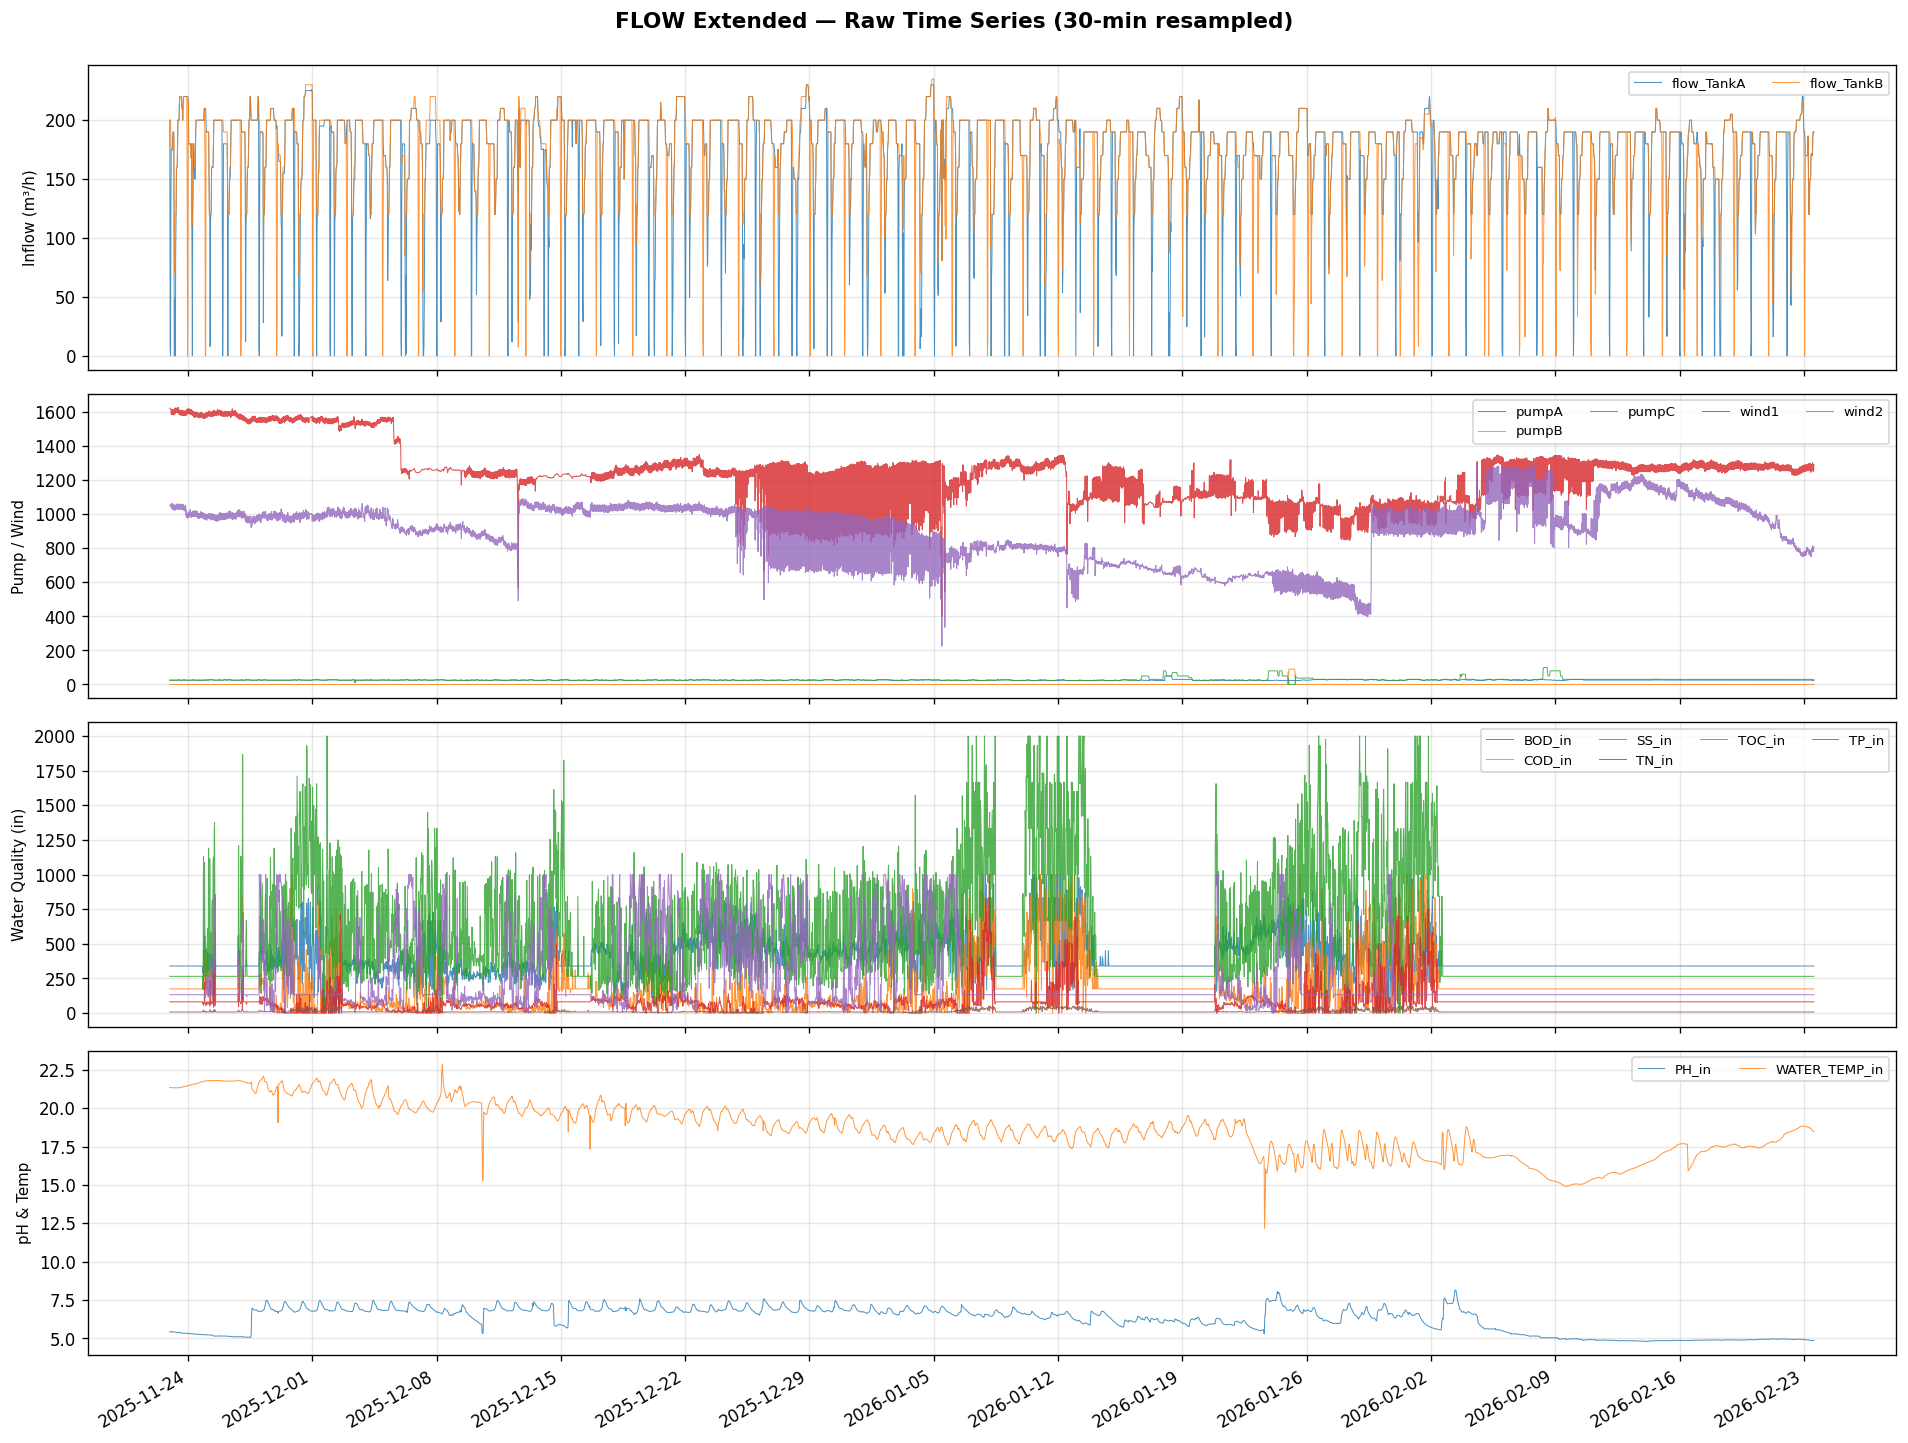

Saved: flow_extended_timeseries.png


In [6]:
# 컬럼을 의미 그룹으로 나눔
FLOW_GROUPS = {
    'Inflow (m³/h)':      ['flow_TankA', 'flow_TankB'],
    'Pump / Wind':        ['pumpA', 'pumpB', 'pumpC', 'wind1', 'wind2'],
    'Water Quality (in)': ['BOD_in', 'COD_in', 'SS_in', 'TN_in', 'TOC_in', 'TP_in'],
    'pH & Temp':          ['PH_in', 'WATER_TEMP_in'],
}
PALETTE = plt.cm.tab10.colors

flow_30m = flow.resample('30min').mean()

n_groups = len(FLOW_GROUPS)
fig, axes = plt.subplots(n_groups, 1, figsize=(16, 12), sharex=True)
fig.suptitle('FLOW Extended — Raw Time Series (30-min resampled)', fontsize=13, fontweight='bold', y=0.998)

for ax, (group_name, cols) in zip(axes, FLOW_GROUPS.items()):
    for j, col in enumerate(cols):
        ax.plot(flow_30m.index, flow_30m[col], label=col, color=PALETTE[j], alpha=0.8)
    ax.set_ylabel(group_name, fontsize=9)
    ax.legend(fontsize=8, loc='upper right', ncol=min(len(cols), 4))

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
fig.savefig(OUT / 'flow_extended_timeseries.png', bbox_inches='tight')
plt.show()
print('Saved: flow_extended_timeseries.png')

## 5. FLOW — 분포 (Histogram + Boxplot)

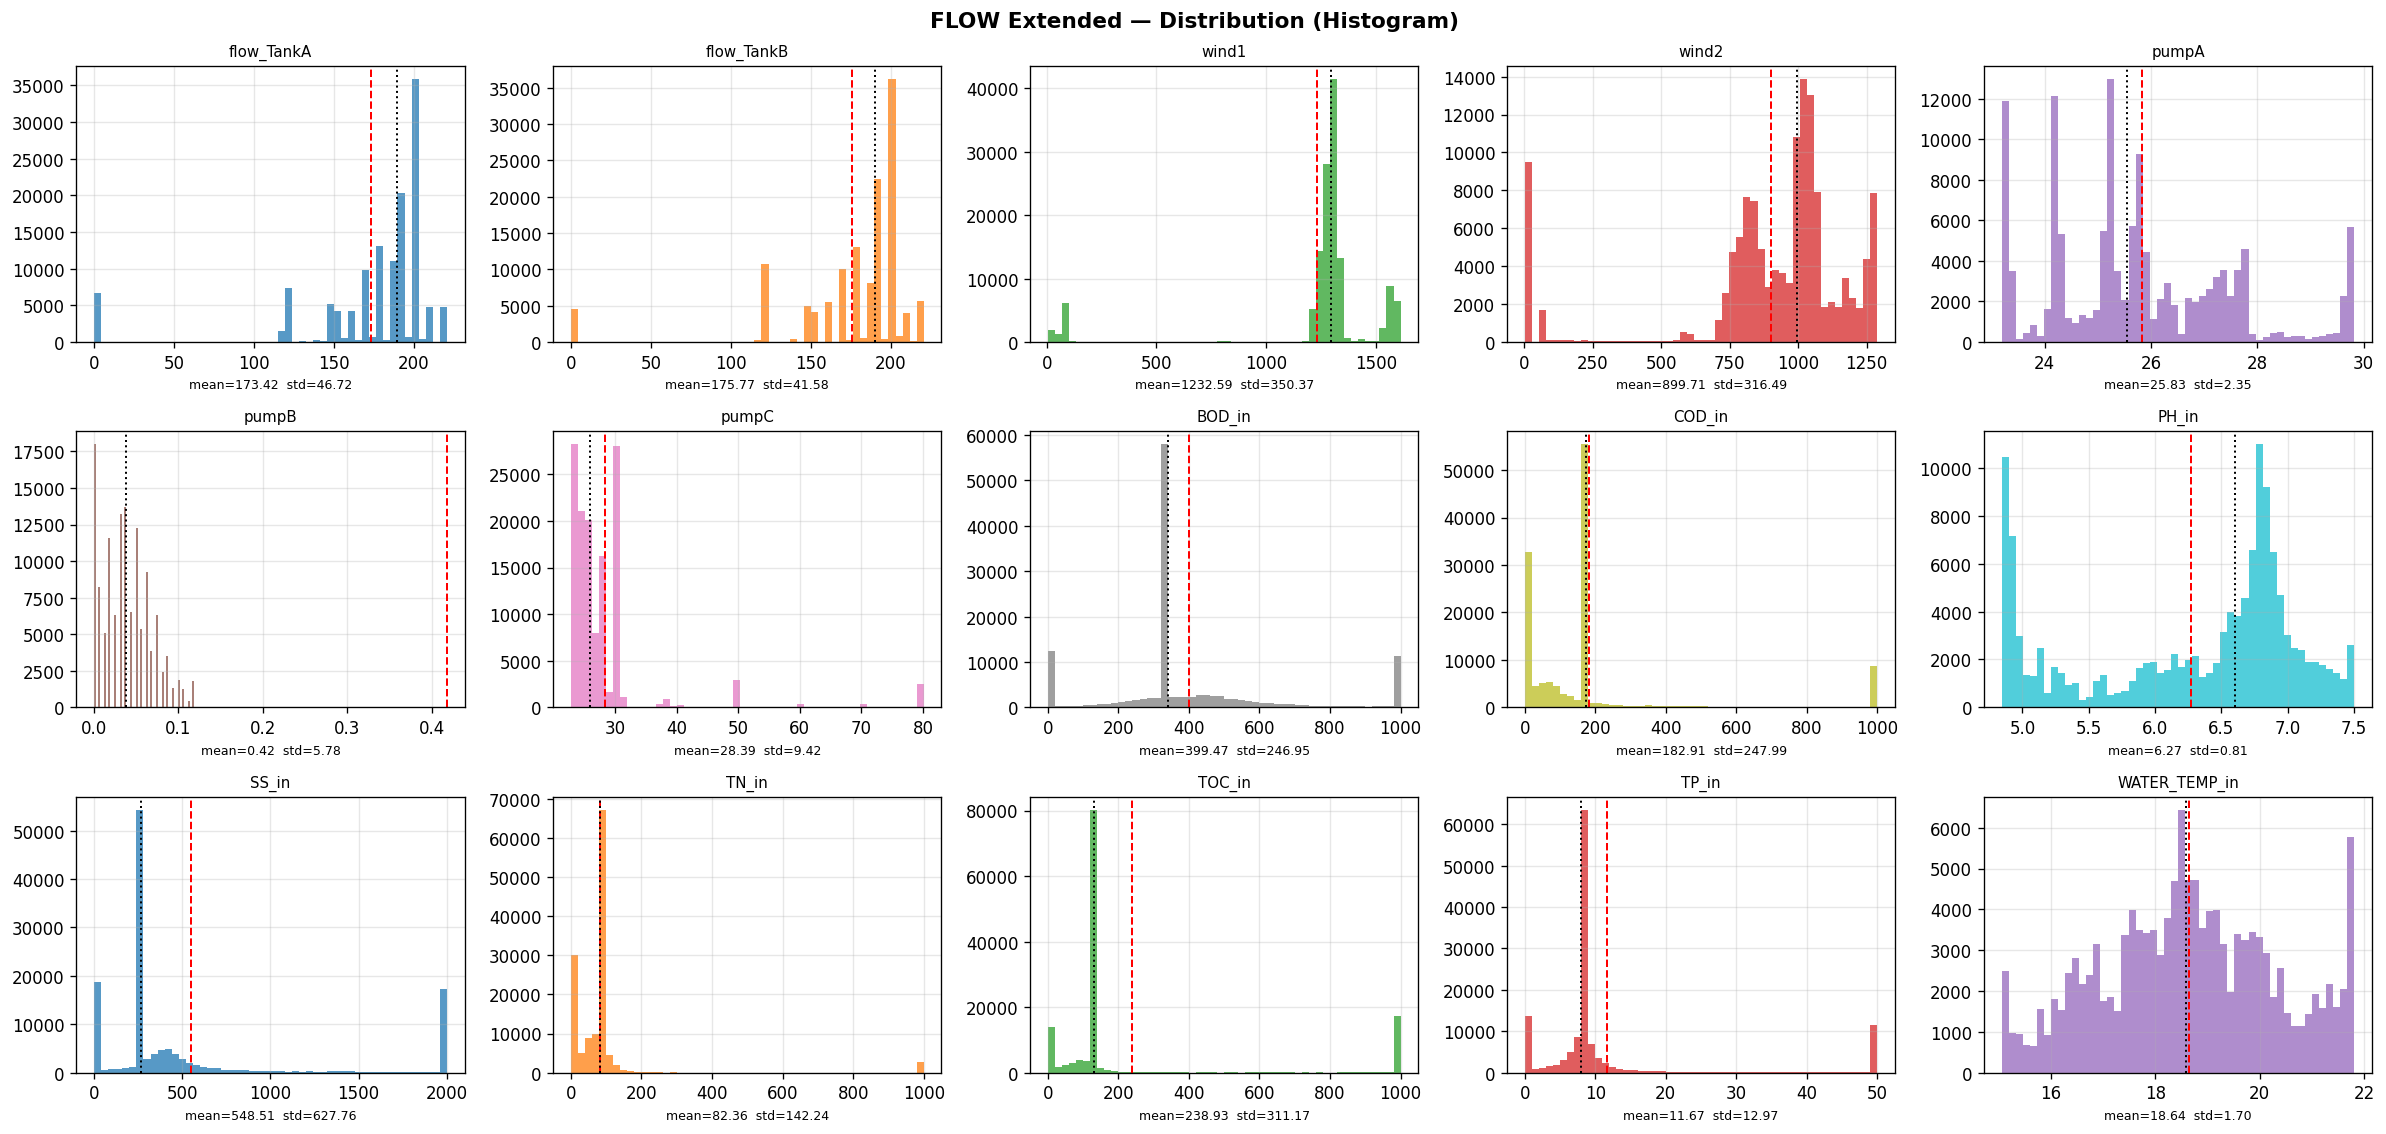

Saved: flow_extended_distribution.png


In [7]:
FLOW_ALL_COLS = [
    'flow_TankA', 'flow_TankB',
    'wind1', 'wind2',
    'pumpA', 'pumpB', 'pumpC',
    'BOD_in', 'COD_in', 'PH_in', 'SS_in', 'TN_in', 'TOC_in', 'TP_in', 'WATER_TEMP_in'
]
n = len(FLOW_ALL_COLS)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.2))
fig.suptitle('FLOW Extended — Distribution (Histogram)', fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(FLOW_ALL_COLS):
    ax = axes_flat[i]
    s = flow[col].dropna()
    q1, q3 = s.quantile(0.01), s.quantile(0.99)
    s_clip = s.clip(q1, q3)
    color = PALETTE[i % len(PALETTE)]

    ax.hist(s_clip, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(s.mean(), color='red', lw=1.2, linestyle='--')
    ax.axvline(s.median(), color='black', lw=1.2, linestyle=':')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(f'mean={s.mean():.2f}  std={s.std():.2f}', fontsize=7.5)

# 남은 axes 숨기기
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
fig.savefig(OUT / 'flow_extended_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: flow_extended_distribution.png')

## 6. 결측 현황 요약

In [8]:
def missing_summary(df, name):
    total = len(df)
    miss = df.isnull().sum()
    pct  = (miss / total * 100).round(2)
    summary = pd.DataFrame({'missing': miss, 'pct(%)': pct})
    print(f'\n=== {name} 결측 요약 (총 {total:,}행) ===')
    display(summary[summary.missing > 0] if miss.any() else pd.DataFrame({'info': ['결측 없음']}))

missing_summary(tms, 'TMS')
missing_summary(flow, 'FLOW')


=== TMS 결측 요약 (총 726,665행) ===


,missing,pct(%)
TOC_VU,102757,14.14
PH_VU,102757,14.14
SS_VU,102757,14.14
FLUX_VU,102752,14.14
TN_VU,102753,14.14
TP_VU,102757,14.14



=== FLOW 결측 요약 (총 132,297행) ===


,info
0,결측 없음


In [9]:
print('Done — 저장된 파일 목록:')
for f in sorted(OUT.glob('*.png')):
    print(f'  {f.name}')

Done — 저장된 파일 목록:
  aws368_normalized.png
  aws368_plot.png
  aws541_normalized.png
  aws541_plot.png
  aws569_normalized.png
  aws569_plot.png
  flow_extended_distribution.png
  flow_extended_timeseries.png
  flow_normalized.png
  flow_plot.png
  tms_extended_distribution.png
  tms_extended_timeseries.png
  tms_normalized.png
  tms_plot.png
